# MXN441: Assignment 2 Code

**Authors:**  
Jack Fewtrell (n11278331)   
Madeline Miller (n10267646)   

**Selected Paper:**    
*Hybrid ViT-CNN Network for Fine-Grained Image Classification*   

**Description:**  
This notebook contains code developed for Assignment 2 in MXN441, based on the selected paper above.

## Required packages 


In [38]:
import numpy as np
import pandas as pd
import re

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
# VIT  
from torchvision import transforms
from torchvision.models.vision_transformer import VisionTransformer
from torchvision.models import vit_b_16, ViT_B_16_Weights

# Pillow for images 
from PIL import Image

# Test train split 
from sklearn.model_selection import train_test_split

# Progress bar 
from tqdm import tqdm

import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import time
import torch

from torch.optim.lr_scheduler import CosineAnnealingLR

# Plots
import matplotlib.pyplot as plt

## Importing Data 

The version of the dataset can be found on Kaggle, due to the size of the data set, it cannot be included in the submission. A source link can be found in Appendix A of the report.

The dataset is imported by following the process below. 

In [39]:
# Accessing the classes 
nclass = 200 # number of classes 
classes = []

# Path to the folder containing the CUB-200-2011 dataset
data_location = "Data/CUB_200_2011/CUB_200_2011/"
#data_location = r"C:\Users\n10267646\Downloads\CUB_200_2011\CUB_200_2011" # for Maddy


with open(f"{data_location}/classes.txt") as f:
  for x in f:
    match = re.search(r"\d+\.[A-Za-z_]+", x)
    if match:
        classes.append(match.group(0))

# Accessing the image names and ID's 
image_ids = []
image_names = []
with open(f"{data_location}/images.txt") as f:
  for x in f:
    match = re.search(r"(\d+)\s+(.+)", x)
    if match:
        image_ids.append(match.group(1))
        image_names.append(match.group(2))

# Getting image class labels 
image_classes = []
with open(f"{data_location}/image_class_labels.txt") as f:
    for x in f: 
        match = re.search(r" (\d+)", x)
        if match:
            temp = (match.group(1))
            image_classes.append(classes[int(temp) - 1])

# import the path to the images 
image_path = []
for x in range(len(image_names)):
    image_path.append(f"{data_location}/images/{image_names[x]}")

# importing provided training and testing sets 
isTraining = [] 
with open(f"{data_location}/train_test_split.txt") as f:
    for x in f: 
        match = re.search(r"(\d+) (\d+)", x) 
        if match:
            isTraining.append(int(match.group(2)))

# creating a data frame, listing Images and their subsequent locations 
data = {
    "ID": image_ids,
    "Name": image_names,
    "Class": image_classes,
    "Image Path": image_path,
    "isTraining": isTraining
}

df = pd.DataFrame(data)


In [40]:
# Creating map of classes 
classes_unique = sorted(df["Class"].unique())
label_map = {c: i for i, c in enumerate(classes_unique)}

## Data Preprocessing 

The CUB dataset provides coordinates specifying the location of each bird within an image. The code below loads these coordinates and stores the associated boundary box information.

In [41]:
# Initialise dictionary to store bounding box coordinates for each image
bbox_dict = {}

with open(f"{data_location}/bounding_boxes.txt") as f:
    for line in f:
        # Split each line into image ID and boundary box values
        parts = line.strip().split()
        # Extract image ID
        img_id = int(parts[0])  
        # Extract boundary box coordinates
        x, y, w, h = map(float, parts[1:]) # (x,y) = position of top-left corner, (w,h) = width and height of boundary box in pixels
        # Store bounding box information using image ID as the key
        bbox_dict[img_id] = (x, y, w, h)   

The function below is used for image preprocessing. Each image is cropped to its bounding box with additional padding applied around the border. The cropped image is then resized to the specified dimensions. 

In [42]:
# Defining image preprocessing pipeline 
def getImage(path, size, img_ID, bbox_dict, pad = 0.15):
    """
    Image preprocessing pipeline
    Loads an image from path, applies bounding box cropping with padding, and resizes the image for use in the ML models.

    Input:
    path (str): path to image.
    size (int): output image size.
    img_ID (int): image ID used to access boundary box information in bbox_dict.
    bbox_dict (dict): dictionary containing boundary box information.
    pad (float): % padding added around bounding box.

    Output: 
    image: PIL.Image.
    
    """
    # Open image 
    img = Image.open(path).convert("RGB")
    # Copy a local instance
    image = img.copy()
    # Close original image 
    img.close()

    # Get bounding box information
    x, y, w, h = bbox_dict[img_ID]

    # Get image dimensions
    img_w, img_h = image.size
    
    # Compute padding to add to boundary box (in pixels)
    pad_w = w * pad
    pad_h = h * pad

    # Define padded crop coordinates
    x1 = max(0, int(x - pad_w))
    y1 = max(0, int(y - pad_h))
    x2 = min(img_w, int(x + w + pad_w))
    y2 = min(img_h, int(y + h + pad_h))

    # Crop image using bounding box
    image = image.crop((x1, y1, x2, y2))

    # Resize cropped image
    image = image.resize((size, size))

    # Return processed image 
    return(image)

### Data Split 

The dataset was split into training, validation, and test sets using a stratified 70/15/15 split.

In [43]:
# Set seed for reproducibility
seed = 10

# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df, 
    test_size=0.30, 
    stratify=df["Class"], 
    random_state=seed
)

# Second split: split 30% temp into 15% val and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Class"],
    random_state=seed
)

# Extract IDs
trainID = train_df["ID"]
valID = val_df["ID"]
testID = test_df["ID"]

## Preprocessing example

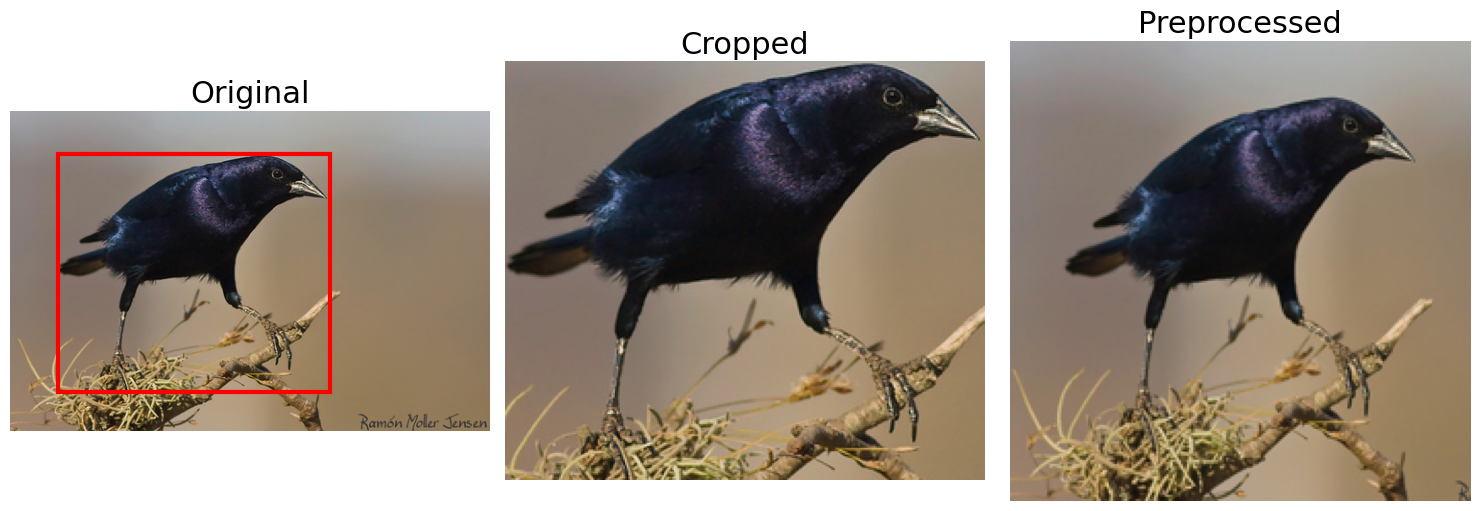

In [34]:
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

# ---------------------------------------------------------
# Example image
# ---------------------------------------------------------

# Select example image path + image ID
example_path = train_df.iloc[0]["Image Path"]
example_id = int(train_df.iloc[0]["ID"])

# ---------------------------------------------------------
# 1. Original image
# ---------------------------------------------------------

original_img = Image.open(example_path).convert("RGB")

# ---------------------------------------------------------
# 2. Bounding-box cropped image
# ---------------------------------------------------------

# Get bounding box coordinates
x, y, w, h = bbox_dict[example_id]

# Copy image
cropped_img = original_img.copy()

# Crop using bounding box only
cropped_img = cropped_img.crop(
    (int(x), int(y), int(x + w), int(y + h))
)

# ---------------------------------------------------------
# 3. Fully preprocessed image
# ---------------------------------------------------------

processed_img = getImage(
    example_path,
    size=224,
    img_ID=example_id,
    bbox_dict=bbox_dict,
    pad=0.15
)

# ---------------------------------------------------------
# Create 1x3 figure
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---------------- Original ----------------

axes[0].imshow(original_img)
axes[0].set_title(
    "Original",
    fontsize=22
)

# Draw bounding box
rect = patches.Rectangle(
    (x, y),
    w,
    h,
    linewidth=3,
    edgecolor='red',
    facecolor='none'
)

axes[0].add_patch(rect)
axes[0].axis("off")

# ---------------- Cropped ----------------

axes[1].imshow(cropped_img)
axes[1].set_title(
    "Cropped",
    fontsize=22
)
axes[1].axis("off")

# ---------------- Preprocessed ----------------

axes[2].imshow(processed_img)
axes[2].set_title(
    "Preprocessed",
    fontsize=22
)
axes[2].axis("off")

plt.tight_layout()

# ---------------------------------------------------------
# Save figure
# ---------------------------------------------------------

plt.savefig(
    "preprocessing_pipeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Paper Method Replication

**Selective Kernel (SK) Module**   

(Required for MIT module)

In [46]:
class SKUnit(nn.Module):
    """
    Selective Kernel (SK) Unit.

    Applies multi-scale convolution (kernel sizes: 3 and 5) and learns channel-wise attention to adaptively fuse them.

    Args:
        D (int): Number of input channels.
        r (int): Reduction ratio for bottleneck.

    Input:
        x (Tensor): Shape (B, D, H, W)

    Output:
        V (Tensor): Shape (B, D, H, W)
    """
    
    def __init__(self, D=32, r=4):

        super().__init__()
        
        # Store hyperparameters
        self.D = D
        self.r = r

        # --- Split: two convolution branches ---
        # Branch 1: 3*3
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=D, out_channels=D, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(D),
            nn.ReLU(inplace=True)
        )
        
        # Branch 2: 5*5
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=D, out_channels=D, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(D),
            nn.ReLU(inplace=True)
        )

        # --- Fuse: channel reduction  ---
        d = D // r # reduced channel dimension
        self.fc1 = nn.Linear(in_features=D, out_features=d, bias=False) 
        self.bn = nn.BatchNorm1d(d)            
        self.relu = nn.ReLU(inplace=True)   

        # --- Select: compute attention weights ---
        self.fc2 = nn.Linear(in_features=d, out_features=2*D, bias=False) 

    def forward(self, x):
        B, D, H, W = x.shape  

        # --- Split ---
        U1 = self.conv3(x)          # (B, D, H, W)
        U2 = self.conv5(x)          # (B, D, H, W)

        # --- Fuse ---
        # combine branches
        U = U1 + U2 
        
        # global average pooling
        s = U.mean(dim=(2, 3))      # (B, D)
        
        # channel reduction
        z = self.fc1(s)             # (B, d)
        z = self.bn(z)
        z = self.relu(z)

        # --- Select ---
        # compute attention
        attn = self.fc2(z)              # (B, 2D)
        attn = attn.view(B, 2, D)       # (B, 2, D)
        attn = F.softmax(attn, dim=1)   # across branches

        # extract branch weights
        a = attn[:, 0].unsqueeze(-1).unsqueeze(-1)  # (B, D, 1, 1)
        b = attn[:, 1].unsqueeze(-1).unsqueeze(-1)

        # weighted aggregation
        V = a * U1 + b * U2   # (B, D, H, W)
        
        return V

**Multi-scale Image-to-Tokens (MIT) module** 

In [47]:
class MIT(nn.Module):
    """
    Multi-scale Image-to-Tokens (MIT) module.

    Converts an image into a sequence of tokens using CNN feature extraction + patch embedding.

    Args:
        d (int): Token embedding dimension.
        D (int): CNN feature channels.
        P (int): Patch size.

    Input:
        x (Tensor): Shape (B, 3, H, W)

    Output:
        x (Tensor): Shape (B, N+1, d)
    """
    
    def __init__(self, d=384, D=32, P=4):

        super().__init__()

        # Store hyperparameters
        self.P = P 
        self.d = d  
        self.D = D 

        # --- Initial convolution + downsampling ---
        self.conv = nn.Conv2d(in_channels=3, out_channels=D, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn = nn.BatchNorm2d(D)                                                    
        self.pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # --- Selective Kernel ---
        self.sk = SKUnit(D, r=4)

        # --- Patch extraction ---
        self.unfold = nn.Unfold(kernel_size=P, stride=P) # extract non-overlapping P*P patches
        
        # --- Patch projection ---
        self.proj = nn.Linear(in_features=P*P*D, out_features=d) # map each patch to token embedding
    
        # add class token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d))

    def forward(self, x):
        B = x.shape[0] # extract batch size

        # --- Initial convolution + downsampling ---
        x = self.conv(x)        # (B, D, H/2, W/2)
        x = self.bn(x)
        x = self.pool(x)        # (B, D, H/4, W/4)

        # --- SK unit ---
        x = self.sk(x)

        # --- Patch extraction ---
        x = self.unfold(x)      # (B, D*P*P, N)
        x = x.transpose(1,2)    # (B, N, D*P*P)

        # --- Patch projection ---
        x = self.proj(x)        # (B, N, d)

        # create class token
        cls = self.cls_token.expand(B, -1, -1)  # (B, 1, d)
        # prepend CLS token to patch tokens
        x = torch.cat([cls, x], dim=1)          #  (B, N+1, d)

        return x 

**Mixed Depthwise Convolution (MixConv) module** 

(Required for MCF module) 

The paper does not specify whether an equal or exponential channel partitioning method was used. Here, we use equal partitioning. This requires input channels to be divisible by the number of groups. The paper specifies kernel sizes (3, 5, 7).

In [48]:

class MixConv(nn.Module):
    """
    Mixed Depthwise Convolution (MixConv).

    Splits input channels into equal groups, applies depthwise convolution
    with a distinct kernel size to each group, and then concatenates the results.

    Args:
        in_channels (int): Number of input channels (C).
        kernel_sizes (list[int]): Kernel sizes per group (e.g. [3, 5, 7]).

    Input:
        x (Tensor): Shape (B, C, H, W)

    Output:
        Y (Tensor): shape (B, C, H, W)
    """

    def __init__(self, in_channels=512, kernel_sizes=(3, 5, 7)):
        super().__init__()

        # Store hyperparameters
        self.in_channels = in_channels
        self.kernel_sizes = list(kernel_sizes)
        num_groups = len(self.kernel_sizes)

        # --- Channel-wise partitioning ---
        # Split channels evenly across groups
        splits = [in_channels // num_groups] * num_groups
        self.splits = splits

        # --- Multi-scale depth-wise convolution ---
        self.convs = nn.ModuleList()
        for c, k in zip(self.splits, self.kernel_sizes):
            self.convs.append(
                nn.Conv2d(
                    in_channels=c,
                    out_channels=c,
                    kernel_size=k,
                    padding= (k-1) // 2,   
                    groups=c, # depth-wise convolution
                    bias=True
                )
            )

    def forward(self, x):

        # --- Partition input into groups ---
        x_groups = torch.split(x, self.splits, dim=1)

        # --- Apply multi-scale depth-wise convolution ---
        # (different kernel size for each group)
        y_groups = []
        for conv, xi in zip(self.convs, x_groups):
            y_groups.append(conv(xi))

        # --- Concatenate group outputs ---
        Y = torch.cat(y_groups, dim=1)

        return Y

**Mixed Convolutional Feed-forward (MCF) Module**

In [49]:
class MCF(nn.Module):
"""
Mixed Convolution Feed-Forward (MCF) module.

Replaces the standard transformer feed-forward network with a
convolutional module that combines depth-wise convolution,
channel expansion, and MixConv operations to capture
multi-scale spatial features.

Args:
    dim (int): Token embedding dimension.
    expansion (int): Channel expansion factor applied before
        MixConv.

Input:
    x (Tensor): Token sequence of shape
        (B, N+1, dim).

Output:
    x (Tensor): Updated token sequence of shape
        (B, N+1, dim).
"""

def __init__(self, dim, expansion=4):
    super().__init__()

    # Store hyperparameters
    dim2 = dim * expansion

    # --- Depth-wise convolution ---
    self.dwconv = nn.Conv2d(
        dim,
        dim,
        kernel_size=3,
        padding=1,
        groups=dim
    )
    self.norm1 = nn.BatchNorm2d(dim)

    # --- Channel expansion ---
    self.conv1 = nn.Conv2d(
        dim,
        dim2,
        kernel_size=1
    )
    self.norm2 = nn.BatchNorm2d(dim2)

    # --- Multi-scale convolution ---
    self.mixconv = MixConv(dim2)
    self.norm3 = nn.BatchNorm2d(dim2)

    # --- Channel projection ---
    self.conv2 = nn.Conv2d(
        dim2,
        dim,
        kernel_size=1
    )

    self.act = nn.GELU()

def forward(self, x):

    # --- Extract tensor dimensions ---
    B, N, C = x.shape

    # --- Separate CLS token ---
    cls_token = x[:, :1]
    x = x[:, 1:]

    # --- Reshape tokens to feature map ---
    num_patches = x.shape[1]
    H = W = int(num_patches ** 0.5)

    x = x.reshape(
        B,
        H,
        W,
        C
    ).permute(0, 3, 1, 2)

    # --- Depth-wise convolution ---
    x = self.dwconv(x)
    x = self.norm1(x)
    x = self.act(x)

    # --- Channel expansion ---
    x = self.conv1(x)
    x = self.norm2(x)
    x = self.act(x)

    # --- Multi-scale convolution ---
    x = self.mixconv(x)
    x = self.norm3(x)
    x = self.act(x)

    # --- Channel projection ---
    x = self.conv2(x)

    # --- Restore token sequence ---
    x = x.flatten(2).transpose(1, 2)
    x = torch.cat(
        [cls_token, x],
        dim=1
    )

    return x

**Multi-head Self-attention Layer** 

In [50]:
class MSA(nn.Module):
"""
Multi-Head Self-Attention (MSA).

Applies self-attention to a sequence of input tokens and returns
both the updated token representations and attention weights.

Args:
    dim (int): Token embedding dimension.
    heads (int): Number of attention heads.

Input:
    x (Tensor): Token sequence of shape
        (B, N+1, dim).

Output:
    out (Tensor): Updated token sequence of shape
        (B, N+1, dim).
    attn (Tensor): Multi-head attention weights of shape
        (B, heads, N+1, N+1).
"""
  
    def __init__(self, dim, heads=8):
        super().__init__()
        
        self.attn = nn.MultiheadAttention(
            dim,
            heads ,
            batch_first=True
        )

    def forward(self, x):
        out, attn = self.attn(
            x, x, x,
            need_weights=True,
            average_attn_weights=False  
        )
        

        return out, attn

**Encoder Layer**

In [51]:
class EncoderLayer(nn.Module):
    """
    Transformer encoder layer.

    Consists of a Multi-Head Self-Attention (MSA) module followed
    by a Mixed Convolution Feed-Forward (MCF) module, with residual
    connections and layer normalisation applied before each module.
    
    Args:
        dim (int): Token embedding dimension.
        heads (int): Number of attention heads.

    Input:
        x (Tensor): Token sequence of shape
            (B, N+1, dim).
    
    Output:
        x (Tensor): Updated token sequence of shape
            (B, N+1, dim).
        attn_map (Tensor): Multi-head attention weights of shape
            (B, heads, N+1, N+1).
    """

    def __init__(self, dim, heads = 8):
        super().__init__()
            
        self.norm1 = nn.LayerNorm(dim)
        self.msa = MSA(dim, heads)

        self.norm2 = nn.LayerNorm(dim)
        self.mcf = MCF(dim)

    def forward(self, x):
        # Run MSA Layer 
        attn_out, attn_map = self.msa(self.norm1(x))
        
        x = x + attn_out

        # Run MCF Layer 
        x = x + self.mcf(self.norm2(x))
       
        return x, attn_map
        

In [52]:
class FinalEncoderLayer(nn.Module):

    def __init__(self, dim, heads):
        super().__init__()

        self.norm = nn.LayerNorm(dim)
        self.msa = MSA(dim, heads)

    def forward(self, x):

        attn_out, attn_map = self.msa(self.norm(x))

        x = x + attn_out

        return x, attn_map

**Multi-Layer Feature Selection Module**

In [ ]:
class MFS(nn.Module):
"""
Multi-Layer Feature Selection (MFS).

Selects the top M discriminative patch tokens based on the
Hadamard product of CLS-token attention across all attention heads.

Args:
    M (int): Number of patch tokens to select.

Input:
    attn (Tensor): Multi-head attention weights of shape
        (B, num_heads, N+1, N+1).
    tokens (Tensor): Token features of shape
        (B, N+1, dim).

Output:
    chosen (Tensor): Selected patch tokens of shape
        (B, M, dim).
"""

def __init__(self, M):
    super().__init__()

    # Store hyperparameters
    self.M = M

def forward(self, attn, tokens):

    # --- Extract tensor dimensions ---
    B, num_heads, N_plus_1, _ = attn.shape
    N = N_plus_1 - 1

    # --- Extract CLS-to-patch attention ---
    cls_attn_per_head = attn[:, :, 0, :]
    cls_attn_per_head = cls_attn_per_head[:, :, 1:]

    # --- Aggregate attention using Hadamard product ---
    cls_attn_aggregated = cls_attn_per_head[:, 0, :]

    for h in range(1, num_heads):
        cls_attn_aggregated *= cls_attn_per_head[:, h, :]

    # DISCLAIMER: AI suggested normalising attention scores for stability
    cls_attn_aggregated = cls_attn_aggregated / (cls_attn_aggregated.sum(dim=-1, keepdim=True) + 1e-8)

    # --- Select top M tokens ---
    topk_indices = torch.topk(cls_attn_aggregated, self.M, dim=-1).indices  # (B, M)
        
    # --- Gather selected tokens ---
    batch_idx = torch.arange(B, device=tokens.device).unsqueeze(1)  # (B, 1)
    patch_tokens = tokens[:, 1:, :]  # Exclude CLS token: (B, N, dim)
    chosen = patch_tokens[batch_idx, topk_indices]  # (B, M, dim)

    return chosen

**HVCNet Model**

Following the architecture in figure 1 of the paper, we can develop the following model. 

In [55]:
class HVC(nn.Module):
    def __init__(
        self,  
        dim = 384, 
        depth=10,
        heads=8,
        num_classes= 200,
        M=10
    ):
        super().__init__()
        # MIT Module 
        self.mit = MIT(d=dim)

        # Encoder Block for intermediate layers
        self.feature_layers = nn.ModuleList([
            EncoderLayer(dim, heads)
            for _ in range(depth - 1)
        ])

        # Final encoder layer
        self.final_layer = FinalEncoderLayer(dim, heads)
        
        self.mfs = MFS(M)

        self.head = nn.Linear(dim, num_classes)
        
        self._init_weights()
    
    # DISCLAIMER: _init_weights section was suggested by Claude to stabilise training
    def _init_weights(self):
        """
        Initialize model weights using best practices for transformers.
        """
        for module in self.modules():
            if isinstance(module, nn.Linear):
                # Xavier/Glorot initialization for linear layers
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
                    
            elif isinstance(module, nn.Conv2d):
                # Kaiming initialization for conv layers
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
                    
            elif isinstance(module, (nn.BatchNorm2d, nn.LayerNorm, nn.BatchNorm1d)):
                # Batch/Layer norm: weight=1, bias=0
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
        
        # Special initialization for classification head
        # (smaller std for final layer helps stability)
        nn.init.trunc_normal_(self.head.weight, std=0.01)
        nn.init.constant_(self.head.bias, 0)
        
        # Initialize CLS token in MIT module
        nn.init.trunc_normal_(self.mit.cls_token, std=0.02)

    def forward(self, x):
        # Run MIT to generate patches 
        x = self.mit(x)

        # Run encoder layers
        selected_tokens = []

        for layer in self.feature_layers:
            x, attn = layer(x)
            selected = self.mfs(attn, x)
            selected_tokens.append(selected)

        cls = x[:, :1]

        fused = torch.cat([cls] + selected_tokens, dim=1)
        
        # Output results
        fused, _ = self.final_layer(fused)
        out = self.head(fused[:, 0])

        return out

**Training Model**

In [56]:
class CUBDataset(Dataset):

    def __init__(self, df, transform=None, size=224):
        """
        Initialise dataset.

        Input:
        df (pd.DataFrame): dataframe containing image information.
        transform: torchvision transform pipeline.
        size (int): output image size.
        """
        # --- Store inside class: ---
        self.df = df.reset_index(drop=True) # dataframe
        self.transform = transform          # transform pipeline
        self.size = size                    # output image size (used in getImage)

    def __len__(self):
        """
        Returns number of images in dataset.
        """
        return len(self.df)

    def __getitem__(self, idx):
        """
        Loads and preprocesses a single image.

        Input:
        idx (int): image index.

        Output:
        image: processed image tensor.
        label: integer class label.
        """

        # Get df row corresponding to image index
        row = self.df.iloc[idx]

        # --- Load and preprocess image ---
        # (convert to RGB, crop to bounding box + padding, resize)
        image = getImage(
            path=row["Image Path"],
            size=self.size,
            img_ID=int(row["ID"]),
            bbox_dict=bbox_dict
        )

        # Apply transform pipeline (if transform is specified)
        if self.transform:
            image = self.transform(image)

        # Get class label (integer)
        label = label_map[row["Class"]]
        label = torch.tensor(label, dtype=torch.long)

        # Return image and label as a tuple
        return image, label

In [60]:
# ------------- Transforms -------------
train_transform_vit = transforms.Compose([

    # Random crop + scale augmentation
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    # Random horizontal flip
    transforms.RandomHorizontalFlip(p=0.5),

    # Colour augmentation
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    # Convert to tensor
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.1)
    )
])


test_transform_vit = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------- Datasets-------------
train_dataset_vit = CUBDataset(
    train_df,
    transform=train_transform_vit
)

val_dataset_vit = CUBDataset(
    val_df,
    transform=test_transform_vit
)

test_dataset_vit = CUBDataset(
    test_df,
    transform=test_transform_vit
)


# ------------- Data loaders -------------

train_loader_vit = DataLoader(
    train_dataset_vit,
    batch_size=16,
    shuffle=True,
 #   num_workers=0,
    pin_memory=True
)

val_loader_vit = DataLoader(
    val_dataset_vit,
    batch_size=16,
    shuffle=False,
#    num_workers=0,
    pin_memory=True
)

test_loader_vit = DataLoader(
    test_dataset_vit,
    batch_size=16,
    shuffle=False,
#    num_workers=0,
    pin_memory=True
)

In [33]:
# --- Device ---
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# --- Training configuration ---
num_epochs = 25
patience = 5

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# --- Initialise model ---
HVC_model = HVC(
    dim=384,
    depth=10,
    heads=8,
    num_classes=nclass,
    M=10
).to(device)

# --- Optimiser ---
optimizer = torch.optim.AdamW(
    HVC_model.parameters(),
    lr=1e-3,
    weight_decay=0.05
)

# --- Learning rate scheduler ---
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

# --- Tracking variables ---
best_acc = 0.0
epochs_no_improve = 0

train_losses_H = []
val_losses_H = []

train_accuracies_H = []
val_accuracies_H = []

# --- Training loop ---
for epoch in range(num_epochs):

    # --- Training ---
    HVC_model.train()

    train_loss = 0.0
    correct = 0
    total = 0

    train_loop = tqdm(
        train_loader_vit,
        desc=f"Epoch {epoch + 1}/{num_epochs}"
    )

    for imgs, labels in train_loop:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = HVC_model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            HVC_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        train_loop.set_postfix(
            loss=loss.item(),
            acc=correct / total
        )

    train_loss /= total
    train_acc = correct / total

    train_losses_H.append(train_loss)
    train_accuracies_H.append(train_acc)

    # --- Validation ---

    HVC_model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    val_loop = tqdm(
        val_loader_vit,
        desc=f"Epoch {epoch + 1}/{num_epochs} [Val]"
    )

    with torch.no_grad():

        for imgs, labels in val_loop:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = HVC_model(imgs)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loop.set_postfix(
                loss=loss.item(),
                acc=correct / total
            )

    val_loss /= total
    val_acc = correct / total

    val_losses_H.append(val_loss)
    val_accuracies_H.append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1}: "
        f"lr={current_lr:.6f}, "
        f"train_loss={train_loss:.4f}, "
        f"train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, "
        f"val_acc={val_acc:.4f}"
    )

    scheduler.step()

    # --- Save best model ---
    if val_acc > best_acc:

        best_acc = val_acc
        epochs_no_improve = 0

        torch.save(
            HVC_model.state_dict(),
            "HVCNet_scratch.pth"
        )

    else:

        epochs_no_improve += 1

        print(
            f"No improvement for "
            f"{epochs_no_improve} epoch(s)"
        )

    # --- Early stopping ---

    if epochs_no_improve >= patience:

        print("Early stopping triggered")
        break

# --- Load best model ---
HVC_model.load_state_dict(
    torch.load(
        "HVCNet_scratch.pth",
        map_location=device
    )
)

print("Training complete")
print(f"Best validation accuracy: {best_acc:.4f}")

Epoch 1/25 [Val]: 100%|████████████████████████████████████████| 111/111 [00:08<00:00, 12.63it/s, acc=0.0764, loss=4.2]


Epoch 1: lr = 0.000200, train loss = 5.2667, train acc = 0.0353, val loss = 4.6549, val acc = 0.0764


Epoch 2/25 [Val]: 100%|████████████████████████████████████████| 111/111 [00:10<00:00, 10.56it/s, acc=0.275, loss=2.69]


Epoch 2: lr = 0.000199, train loss = 4.0398, train acc = 0.1687, val loss = 3.5086, val acc = 0.2755


Epoch 3/25 [Val]: 100%|█████████████████████████████████████████| 111/111 [00:10<00:00, 10.47it/s, acc=0.373, loss=2.7]


...

Epoch 23: lr = 0.000024, train loss = 1.0523, train acc = 0.9938, val loss = 2.2586, val acc = 0.6482


Epoch 24/25 [Val]: 100%|███████████████████████████████████████| 111/111 [00:11<00:00, 10.09it/s, acc=0.611, loss=2.12]


Epoch 24: lr = 0.000054, train loss = 1.0710, train acc = 0.9922, val loss = 2.3214, val acc = 0.6114
No improvement for 1 epoch(s)


Epoch 25/25 [Val]: 100%|███████████████████████████████████████| 111/111 [00:10<00:00, 10.47it/s, acc=0.606, loss=2.17]
C:\Users\Jack\AppData\Local\Temp\ipykernel_43556\744554774.py:342: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on Gi

Epoch 25: lr = 0.000095, train loss = 1.1141, train acc = 0.9849, val loss = 2.3733, val acc = 0.6063
No improvement for 2 epoch(s)
Training complete


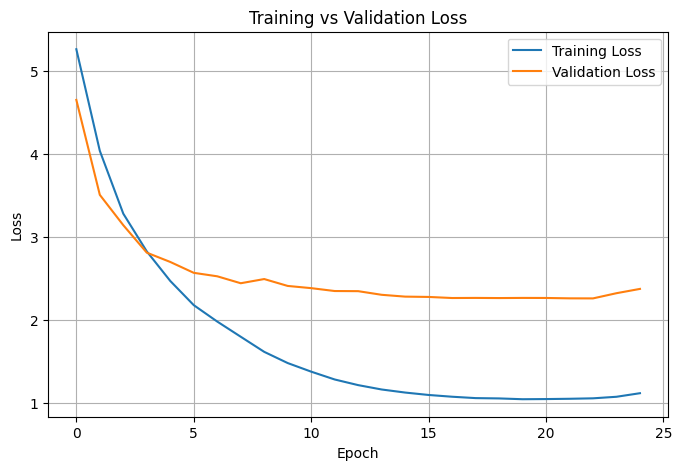

In [58]:
#--- Plot training and validation loss vs. epoch ---

plt.figure(figsize=(8, 5))

plt.plot(train_losses_H, label="Training Loss")
plt.plot(val_losses_H, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

The below code loads the pretrained ResNet50 model with ImageNet weights and adapts it for the CUB dataset by replacing the final classification layer with a 200 class output layer. All pretrained layers are frozen, except for the final residual block (layer4) and classification layer which are finetuned. Class labels are also encoded as integer labels.

The training and validation/testing transform pipelines are shown below. Images must undergo the same preprocessing used for pretrained ResNet50 - images are already resized to 224*224 during preprocessing, but still require normalization using the ImageNet mean and standard deviation used by ResNet50. Additionally, data augmentation is used for training images.

In [67]:
# --- Transform pipeline for training data ---
train_transform = transforms.Compose([

    # Data augmentation 
    transforms.RandomHorizontalFlip(p=0.5),               # random horizontal flip
    transforms.RandomRotation(degrees=10),                # random rotation
    transforms.ColorJitter(brightness=0.1, saturation=0.1, 
                           contrast=0.1), # random brightness and contrast adjustment

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet mean and standard deviation
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --- Transform pipeline for validation/testing ---
test_transform = transforms.Compose([

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet mean and standard deviation
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

The code block below defines a custom dataset class for the CUB-200-2011 dataset. For a given image index, the dataset loads the corresponding image, applies preprocessing using the getImage() function (RGB conversion, bounding box cropping with padding, and resizing), applies the transform pipeline, and returns the processed image tensor together with its integer class label.

In [68]:
class CUBDataset(Dataset):

    def __init__(self, df, transform=None, size=224):
        """
        Initialise dataset.

        Input:
        df (pd.DataFrame): dataframe containing image information.
        transform: torchvision transform pipeline.
        size (int): output image size.
        """
        # --- Store inside class: ---
        self.df = df.reset_index(drop=True) # dataframe
        self.transform = transform          # transform pipeline
        self.size = size                    # output image size (used in getImage)

    def __len__(self):
        """
        Returns number of images in dataset.
        """
        return len(self.df)

    def __getitem__(self, idx):
        """
        Loads and preprocesses a single image.

        Input:
        idx (int): image index.

        Output:
        image: processed image tensor.
        label: integer class label.
        """

        # Get df row corresponding to image index
        row = self.df.iloc[idx]

        # --- Load and preprocess image ---
        # (convert to RGB, crop to bounding box + padding, resize)
        image = getImage(
            path=row["Image Path"],
            size=self.size,
            img_ID=int(row["ID"]),
            bbox_dict=bbox_dict
        )

        # Apply transform pipeline (if transform is specified)
        if self.transform:
            image = self.transform(image)

        # Get class label (integer)
        label = row["Label"]

        # Return image and label as a tuple
        return image, label

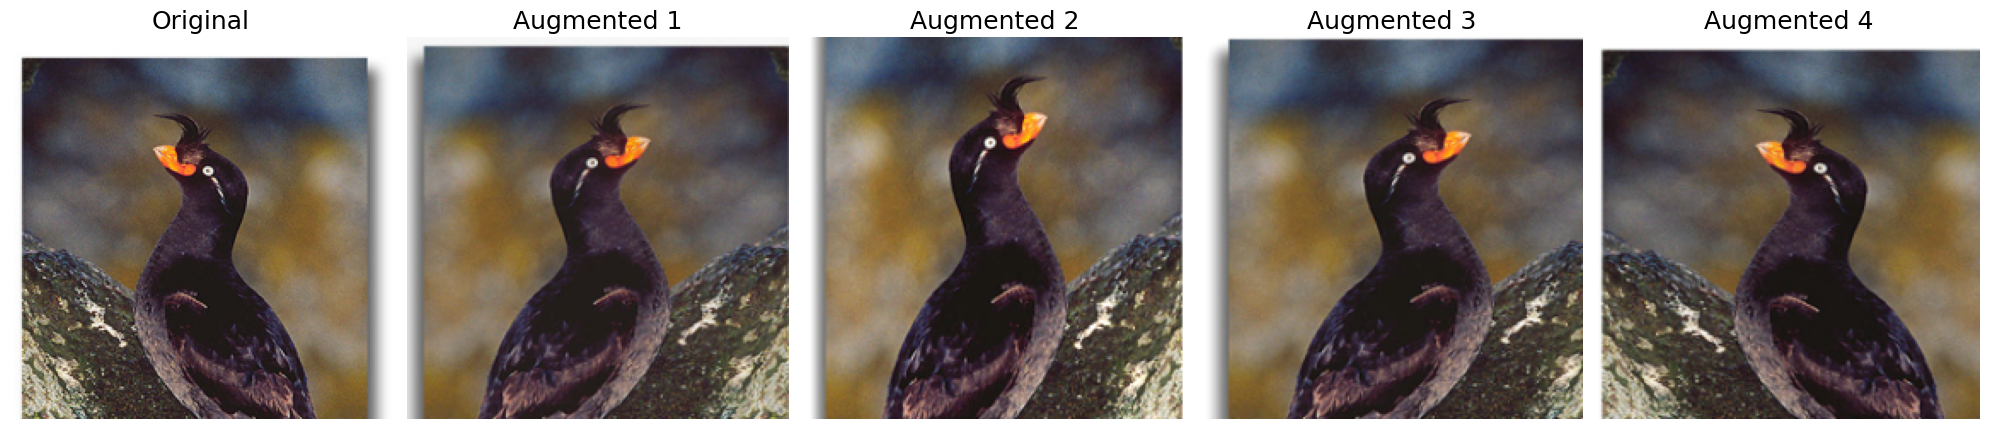

In [95]:
import matplotlib.pyplot as plt
import torch
from PIL import Image

# ---------------------------------------------------------
# Example image
# ---------------------------------------------------------

example_path = train_df.iloc[180]["Image Path"]

example_id = int(train_df.iloc[0]["ID"])

original_img = getImage(
    example_path,
    size=224,
    img_ID=example_id,
    bbox_dict=bbox_dict,
    pad=0.15
)

# ---------------------------------------------------------
# Helper transform for VISUALISATION ONLY
# (without tensor conversion / normalization)
# ---------------------------------------------------------

augment_vis = transforms.Compose([

    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    )
])

# ---------------------------------------------------------
# Generate 4 augmented versions
# ---------------------------------------------------------

augmented_imgs = []

for _ in range(4):

    aug_img = augment_vis(original_img)

    augmented_imgs.append(aug_img)

# ---------------------------------------------------------
# Plot original + augmentations
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 5)
)

# ---------------- Original ----------------

axes[0].imshow(original_img)

axes[0].set_title(
    "Original",
    fontsize=18
)

axes[0].axis("off")

# ---------------- Augmented ----------------

for i in range(4):

    axes[i + 1].imshow(augmented_imgs[i])

    axes[i + 1].set_title(
        f"Augmented {i+1}",
        fontsize=18
    )

    axes[i + 1].axis("off")

plt.tight_layout()

# ---------------------------------------------------------
# Save figure
# ---------------------------------------------------------

plt.savefig(
    "data_augmentation_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()